# Exercice d'application

- Chargement du dataset IMDB depuis Kaggle

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lakshmi25npathi_imdb_dataset_of_50k_movie_reviews_path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

print('Data source import complete.')

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Data source import complete.


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Prétraitement du text

- Lecture du fichier CSV

In [ ]:
data = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Transformation en minuscule

In [ ]:
import pandas as pd

def Transformation_minuscule (df, column_name):

    df[column_name] = df[column_name].str.lower()
    return df
data = Transformation_minuscule(data, 'review')
data.head()


,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


### La normalisation

In [ ]:
import re

def normalize_text(text):

    # enlever les caractères non alphabétiques
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', '', text)

    # remplacer les multiples espaces par un seul
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Appliquer la normalisation sur la colonne 'review'
data['normalized_review'] = data['review'].apply(normalize_text)

# Vérifier le résultat
data[['review', 'normalized_review']].head()


,review,normalized_review
0,one of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...,a wonderful little production br br the filmin...
2,i thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"petter mattei's ""love in the time of money"" is...",petter matteis love in the time of money is a ...


- nettoyage de texte pour enlever : balises < br/>, ponctuation, chiffres, caractères hors alphabet.

Pour enlever le “bruit”.

In [ ]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def normalize_text(text):
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœu\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'<br />', ' ', text)
    text = re.sub(r'br', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text

def remove_stopwords(text):
    words = word_tokenize(text)
    filtered_words = [w for w in words if w not in stop_words]
    filtered_text = ' '.join(filtered_words)
    return filtered_words

data['cleaned_text'] = data['review'].apply(lambda x: remove_stopwords(normalize_text(x)))

data[['review', 'cleaned_text']].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned_text
0,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,a wonderful little production. <br /><br />the...,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there's a family where a little boy ...,"[basically, theres, family, little, boy, jake,..."
4,"petter mattei's ""love in the time of money"" is...","[petter, matteis, love, time, money, visually,..."


- Retire les mots très fréquents (the, is, are…) car ils n’aident pas la classification.

# Tokenisation

In [ ]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt')

def tokenize_text(text, method="mots"):
    if method == "mots":
        return word_tokenize(text)
    elif method == "phrases":
        return sent_tokenize(text)
    else:
        raise ValueError("Choisir : mots ou phrases.")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
data['tokens'] = data['review'].apply(lambda x: tokenize_text(x, method="mots"))
data

,review,sentiment,normalized_review,cleaned_text,tokens
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the filmin...,"[wonderful, little, production, filming, techn...","[a, wonderful, little, production, ., <, br, /..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[i, thought, this, was, a, wonderful, way, to,..."
3,basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,...","[basically, there, 's, a, family, where, a, li..."
4,"petter mattei's ""love in the time of money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,...","[petter, mattei, 's, ``, love, in, the, time, ..."
...,...,...,...,...,...
49995,i thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,"[thought, movie, right, good, job, wasnt, crea...","[i, thought, this, movie, did, a, down, right,..."
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...,"[bad, plot, bad, dialogue, bad, acting, idioti...","[bad, plot, ,, bad, dialogue, ,, bad, acting, ..."
49997,i am a catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,"[catholic, taught, parochial, elementary, scho...","[i, am, a, catholic, taught, in, parochial, el..."
49998,i'm going to have to disagree with the previou...,negative,im going to have to disagree with the previous...,"[im, going, disagree, previous, comment, side,...","[i, 'm, going, to, have, to, disagree, with, t..."


In [ ]:
data['sentences'] = data['review'].apply(lambda x: tokenize_text(x, method="phrases"))
data

,review,sentiment,normalized_review,cleaned_text,tokens,sentences
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...","[one, of, the, other, reviewers, has, mentione...",[one of the other reviewers has mentioned that...
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production br br the filmin...,"[wonderful, little, production, filming, techn...","[a, wonderful, little, production, ., <, br, /...","[a wonderful little production., <br /><br />t..."
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...","[i, thought, this, was, a, wonderful, way, to,...",[i thought this was a wonderful way to spend t...
3,basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,"[basically, theres, family, little, boy, jake,...","[basically, there, 's, a, family, where, a, li...",[basically there's a family where a little boy...
4,"petter mattei's ""love in the time of money"" is...",positive,petter matteis love in the time of money is a ...,"[petter, matteis, love, time, money, visually,...","[petter, mattei, 's, ``, love, in, the, time, ...","[petter mattei's ""love in the time of money"" i..."
...,...,...,...,...,...,...
49995,i thought this movie did a down right good job...,positive,i thought this movie did a down right good job...,"[thought, movie, right, good, job, wasnt, crea...","[i, thought, this, movie, did, a, down, right,...",[i thought this movie did a down right good jo...
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...,"[bad, plot, bad, dialogue, bad, acting, idioti...","[bad, plot, ,, bad, dialogue, ,, bad, acting, ...","[bad plot, bad dialogue, bad acting, idiotic d..."
49997,i am a catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...,"[catholic, taught, parochial, elementary, scho...","[i, am, a, catholic, taught, in, parochial, el...",[i am a catholic taught in parochial elementar...
49998,i'm going to have to disagree with the previou...,negative,im going to have to disagree with the previous...,"[im, going, disagree, previous, comment, side,...","[i, 'm, going, to, have, to, disagree, with, t...",[i'm going to have to disagree with the previo...


# Analyse exploratoire

### WorldCloud

In [ ]:
!pip install wordcloud

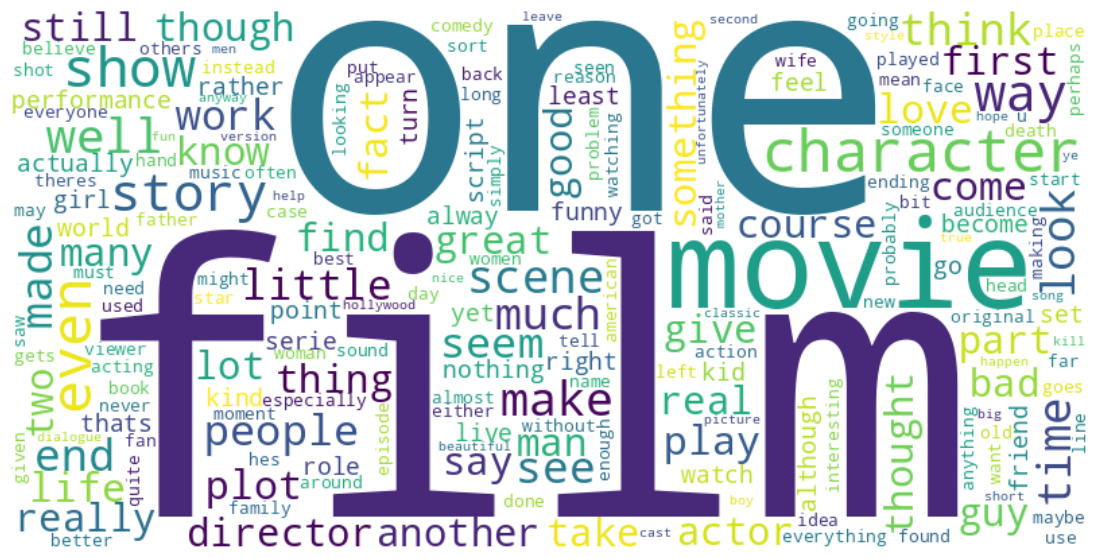

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = ' '.join([' '.join(words) for words in data['cleaned_text']])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


Création de  l'image montrant les mots les plus fréquents.
Visuel utile pour comprendre les thèmes dominants.

# Fréquence des mots

In [ ]:
from collections import Counter
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt

# Convertir les listes de mots en une seule grande liste
all_words = [word for words_list in data["cleaned_text"] for word in words_list]

# Compter les mots
word_counts = Counter(all_words)

# Afficher les 20 mots les plus fréquents
print("Top 20 Most Frequent Words:\n")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")


Top 20 Most Frequent Words:

movie: 85238
film: 76036
one: 51480
like: 39066
good: 28914
even: 24586
would: 24036
time: 23972
really: 23014
see: 22641
story: 22521
well: 19242
much: 19110
get: 18245
bad: 18004
great: 17936
also: 17860
people: 17710
first: 17207
dont: 16976


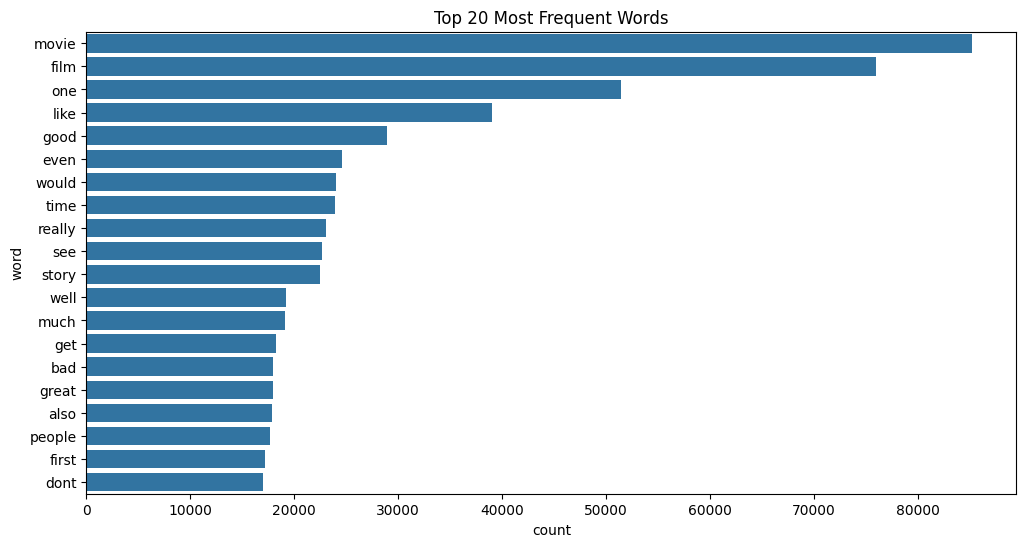

In [ ]:
#afficher les mots sous forme de graphique
import seaborn as sns
import pandas as pd

top20 = word_counts.most_common(20)
df_top20 = pd.DataFrame(top20, columns=["word", "count"])

plt.figure(figsize=(12,6))
sns.barplot(data=df_top20, x="count", y="word")
plt.title("Top 20 Most Frequent Words")
plt.show()


# N-grams (bigrams/trigrams) (subword: 2 grams -> 2 lettres ...)

In [ ]:
from nltk.util import ngrams
from collections import Counter

# générer les bigrams
bigrams_list = list(ngrams(words, 2))

# compter l'occurence des bigrams
bigram_counts = Counter(bigrams_list)

print("\nTop 20 Most Frequent Bigrams:\n")
for bigram, count in bigram_counts.most_common(20):
    print(f"{' '.join(bigram)}: {count}")


# générer les trigrams
trigrams_list = list(ngrams(words, 3))

# compter l'occurence des trigrams
trigram_counts = Counter(trigrams_list)

print("\nTop 20 Most Frequent Trigrams:\n")
for trigram, count in trigram_counts.most_common(20):
    print(f"{' '.join(trigram)}: {count}")


Top 20 Most Frequent Bigrams:

Le vent: 1
vent soufflait: 1
soufflait doucement: 1
doucement sur: 1
sur la: 1
la vallée: 1
vallée .: 1
. Les: 1
Les oiseaux: 1
oiseaux commençaient: 1
commençaient à: 1
à chanter: 1
chanter tandis: 1
tandis que: 1
que le: 1
le soleil: 1
soleil se: 1
se levait: 1
levait .: 1
. Au: 1

Top 20 Most Frequent Trigrams:

Le vent soufflait: 1
vent soufflait doucement: 1
soufflait doucement sur: 1
doucement sur la: 1
sur la vallée: 1
la vallée .: 1
vallée . Les: 1
. Les oiseaux: 1
Les oiseaux commençaient: 1
oiseaux commençaient à: 1
commençaient à chanter: 1
à chanter tandis: 1
chanter tandis que: 1
tandis que le: 1
que le soleil: 1
le soleil se: 1
soleil se levait: 1
se levait .: 1
levait . Au: 1
. Au loin: 1


## Analyse des sentiments

### TF-IDF Vectorisation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convertir les listes de mots en phrases
data["cleaned_text_str"] = data["cleaned_text"].apply(lambda words: " ".join(words))

# Initialiser le vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Appliquer TF-IDF
X = tfidf_vectorizer.fit_transform(data["cleaned_text_str"])

# Afficher la taille de la matrice
print("Shape of TF-IDF matrix (documents, features):")
print(X.shape)


Shape of TF-IDF matrix (documents, features):
(50000, 5000)


- Transforme le texte en matrice numérique pour SVM.

X = matrice (50000 documents × 5000 features)

## Entraînement du modèle SVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Diviser les données
X_train, X_test, y_train, y_test = train_test_split( X, data['sentiment'],  test_size=0.2, random_state=42)

# Initialiser SVM
svm_model = LinearSVC()

# Entraîner
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


### Evaluation du model SVM

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# faire les prédictions
y_pred = svm_model.predict(X_test)

# calculer les metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# générer la matrice de  confusion
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8808
Precision: 0.8809
Recall: 0.8808
F1-Score: 0.8808

Confusion Matrix:
 [[4317  644]
 [ 548 4491]]

Classification Report:
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4961
    positive       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



- le resultat du modèle est environ 88%, ce qui est excellent pour IMDB.

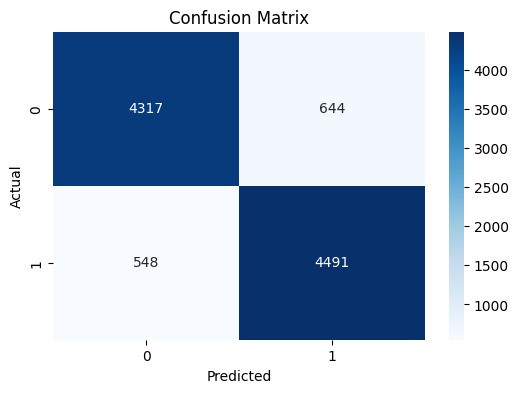

In [ ]:
# Confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


- La heatmap montre un contraste fort sur la diagonale:  le modèle est très performant et équilibré entre les classes.

- Diagonal principale (4317 et 4491): les prédictions correctes pour chaque classe :

Negative correctement classé : 4317

Positive correctement classé : 4491

- Hors-diagonale (644 et 548),  les erreurs :

644 -> reviews négatives prédites comme positives (faux positifs)

548 -> reviews positives prédites comme négatives (faux négatifs)

### TextBlob et Vader

In [ ]:
!pip install vaderSentiment

In [ ]:
from textblob import TextBlob
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# appliquer l'analyse de sentiment TextBlob
data['textblob_sentiment'] = data['cleaned_text'].apply(lambda x: TextBlob(" ".join(x)).sentiment.polarity)

# appliquer VADER
analyzer = SentimentIntensityAnalyzer()
data['vader_sentiment'] = data['cleaned_text'].apply(lambda x: analyzer.polarity_scores(" ".join(x))['compound'])

print("DataFrame après l'analyse de sentiment:")
display(data[['review', 'cleaned_text', 'textblob_sentiment', 'vader_sentiment']])


DataFrame après l'analyse de sentiment:


,review,cleaned_text,textblob_sentiment,vader_sentiment
0,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis...",0.025587,-0.9935
1,a wonderful little production. <br /><br />the...,"[wonderful, little, production, filming, techn...",0.127604,0.9545
2,i thought this was a wonderful way to spend ti...,"[thought, wonderful, way, spend, time, hot, su...",0.278571,0.9692
3,basically there's a family where a little boy ...,"[basically, theres, family, little, boy, jake,...",0.001389,-0.8858
4,"petter mattei's ""love in the time of money"" is...","[petter, matteis, love, time, money, visually,...",0.234551,0.9887
...,...,...,...,...
49995,i thought this movie did a down right good job...,"[thought, movie, right, good, job, wasnt, crea...",0.402591,0.9618
49996,"bad plot, bad dialogue, bad acting, idiotic di...","[bad, plot, bad, dialogue, bad, acting, idioti...",-0.268590,-0.8555
49997,i am a catholic taught in parochial elementary...,"[catholic, taught, parochial, elementary, scho...",0.079949,-0.7615
49998,i'm going to have to disagree with the previou...,"[im, going, disagree, previous, comment, side,...",-0.042725,-0.5267


TEXTBLOB : basé sur un lexique simple. Donne souvent des scores entre -0.2 et +0.2, donc proche du neutre.

Il n’est pas spécialisé pour les sentiments de reviews de films.

-> trop neutre, manque de nuance.

VADER : spécialisé pour les sentiments (réseaux sociaux)

Analyse le contexte : “wonderful”, “amazing”, “hate”, “bad”, etc.

Gère les intensités : “very bad”, “EXTREMELY good!!!”

Conçu pour l’anglais moderne → fonctionne très bien sur IMDB.


->scores plus extrêmes et plus pertinents.